# Employee Attrition Analysis & Prediction
**Dataset:** IBM HR Analytics Employee Attrition Dataset  
**Author:** Jhanavi R R  
**Tools:** Python, Pandas, NumPy, Seaborn, Matplotlib, Scikit-learn, XGBoost  

## Objective
Analyse key factors driving employee attrition at an organisation and build a machine learning model to predict which employees are at risk of leaving.

---
## Step 1: Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2: Load Dataset

**Download the dataset:**
1. Go to: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
2. Download `WA_Fn-UseC_-HR-Employee-Attrition.csv`
3. Place it in the same folder as this notebook

In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
## Step 3: Data Exploration

In [3]:
# Basic info
print('=== DATASET INFO ===')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn Names:\n{list(df.columns)}')

=== DATASET INFO ===
Rows: 1470
Columns: 35

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [4]:
# Data types
print('=== DATA TYPES ===')
print(df.dtypes.value_counts())
print('\nNumerical columns:', df.select_dtypes(include='number').shape[1])
print('Categorical columns:', df.select_dtypes(include='object').shape[1])

=== DATA TYPES ===
int64    26
str       9
Name: count, dtype: int64

Numerical columns: 26
Categorical columns: 9


In [5]:
# Missing values check
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() == 0:
    print('Great! No missing values found.')
else:
    print(missing[missing > 0])

=== MISSING VALUES ===
Total missing values: 0
Great! No missing values found.


In [6]:
# Duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

# Drop useless constant columns
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped constant/ID columns: {cols_to_drop}')
print(f'New shape: {df.shape}')

Duplicate rows: 0
Dropped constant/ID columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape: (1470, 31)


In [7]:
# Statistical summary
print('=== STATISTICAL SUMMARY ===')
df.describe().round(2)

=== STATISTICAL SUMMARY ===


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,2.72,65.89,2.73,2.06,2.73,6502.93,...,3.15,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,1.09,20.33,0.71,1.11,1.10,4707.96,...,0.36,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,...,3.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,2.00,48.00,2.00,1.00,2.00,2911.00,...,3.00,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,3.00,66.00,3.00,2.00,3.00,4919.00,...,3.00,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,4.00,83.75,3.00,3.00,4.00,8379.00,...,3.00,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,4.00,100.00,4.00,5.00,4.00,19999.00,...,4.00,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


=== ATTRITION DISTRIBUTION ===
No (stayed):  1233  (83.9%)
Yes (left):   237  (16.1%)

Class imbalance ratio: 5.2:1


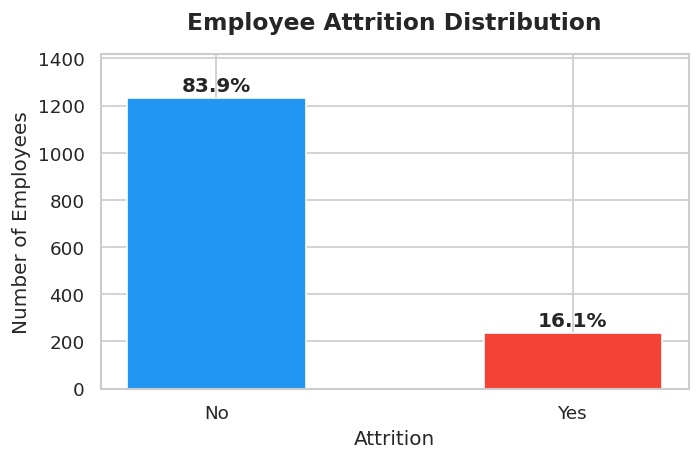

Plot saved!


In [8]:
# Target variable distribution
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print('=== ATTRITION DISTRIBUTION ===')
print(f"No (stayed):  {attrition_counts['No']}  ({attrition_pct['No']:.1f}%)")
print(f"Yes (left):   {attrition_counts['Yes']}  ({attrition_pct['Yes']:.1f}%)")
print(f'\nClass imbalance ratio: {attrition_counts["No"]/attrition_counts["Yes"]:.1f}:1')

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2196F3', '#F44336']
bars = ax.bar(attrition_counts.index, attrition_counts.values, color=colors, width=0.5, edgecolor='white')
for bar, pct in zip(bars, attrition_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Employee Attrition Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.set_ylim(0, max(attrition_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('plot_01_attrition_distribution.png', bbox_inches='tight')
plt.show()
print('Plot saved!')

---
## Step 4: Exploratory Data Analysis (EDA)

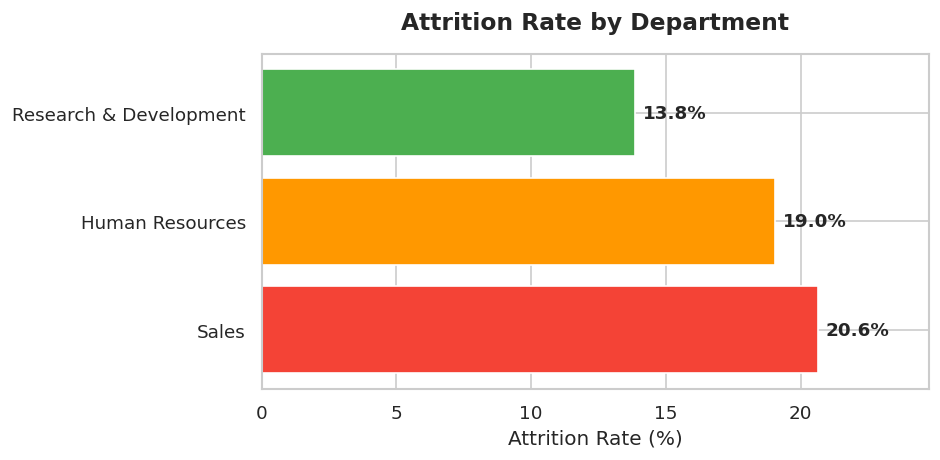

Key Insight: Sales has the highest attrition rate.


In [9]:
# Attrition by Department
dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attr.columns = ['Department', 'AttritionRate']
dept_attr = dept_attr.sort_values('AttritionRate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(dept_attr['Department'], dept_attr['AttritionRate'],
               color=['#F44336', '#FF9800', '#4CAF50'], edgecolor='white')
for bar, val in zip(bars, dept_attr['AttritionRate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition Rate (%)', fontsize=12)
ax.set_xlim(0, dept_attr['AttritionRate'].max() * 1.2)
plt.tight_layout()
plt.savefig('plot_02_attrition_by_department.png', bbox_inches='tight')
plt.show()
print('Key Insight: Sales has the highest attrition rate.')

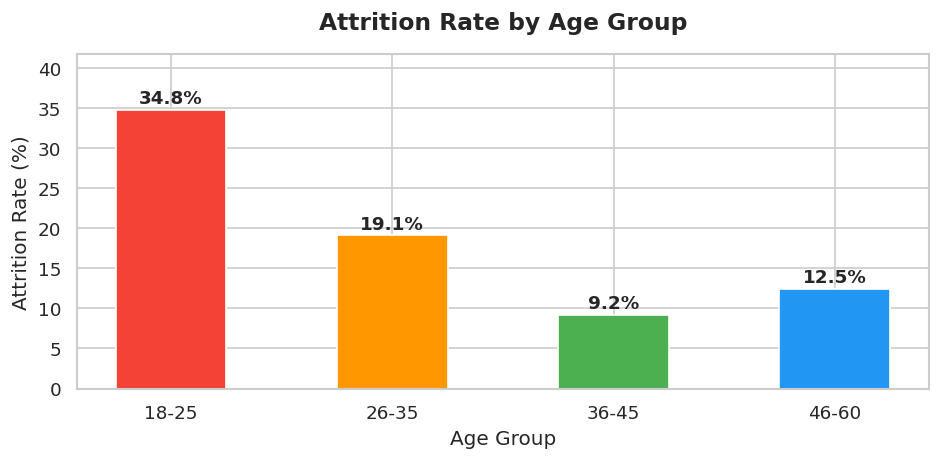

Key Insight: Young employees (18-25) have the highest attrition rate.


In [10]:
# Attrition by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])
age_attr = df.groupby('AgeGroup', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
age_attr.columns = ['AgeGroup', 'AttritionRate']

fig, ax = plt.subplots(figsize=(8, 4))
colors_age = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
bars = ax.bar(age_attr['AgeGroup'].astype(str), age_attr['AttritionRate'],
              color=colors_age, width=0.5, edgecolor='white')
for bar, val in zip(bars, age_attr['AttritionRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Attrition Rate by Age Group', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_ylim(0, age_attr['AttritionRate'].max() * 1.2)
plt.tight_layout()
plt.savefig('plot_03_attrition_by_age.png', bbox_inches='tight')
plt.show()
print('Key Insight: Young employees (18-25) have the highest attrition rate.')

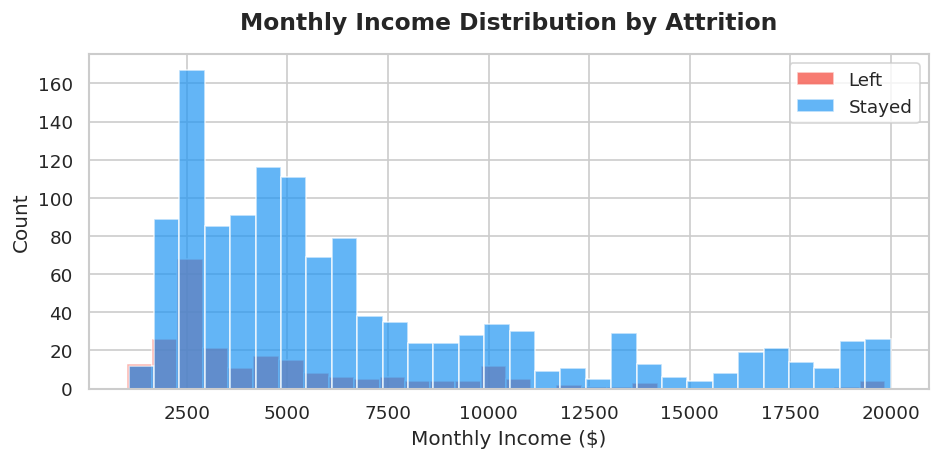

Median income - Left: $3,202 | Stayed: $5,204
Key Insight: Employees who left earned significantly less on average.


In [11]:
# Attrition by Monthly Income
fig, ax = plt.subplots(figsize=(8, 4))
df[df['Attrition']=='Yes']['MonthlyIncome'].hist(
    ax=ax, bins=30, color='#F44336', alpha=0.7, label='Left', edgecolor='white')
df[df['Attrition']=='No']['MonthlyIncome'].hist(
    ax=ax, bins=30, color='#2196F3', alpha=0.7, label='Stayed', edgecolor='white')
ax.set_title('Monthly Income Distribution by Attrition', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Income ($)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_04_income_distribution.png', bbox_inches='tight')
plt.show()

left_median = df[df['Attrition']=='Yes']['MonthlyIncome'].median()
stayed_median = df[df['Attrition']=='No']['MonthlyIncome'].median()
print(f'Median income - Left: ${left_median:,.0f} | Stayed: ${stayed_median:,.0f}')
print('Key Insight: Employees who left earned significantly less on average.')

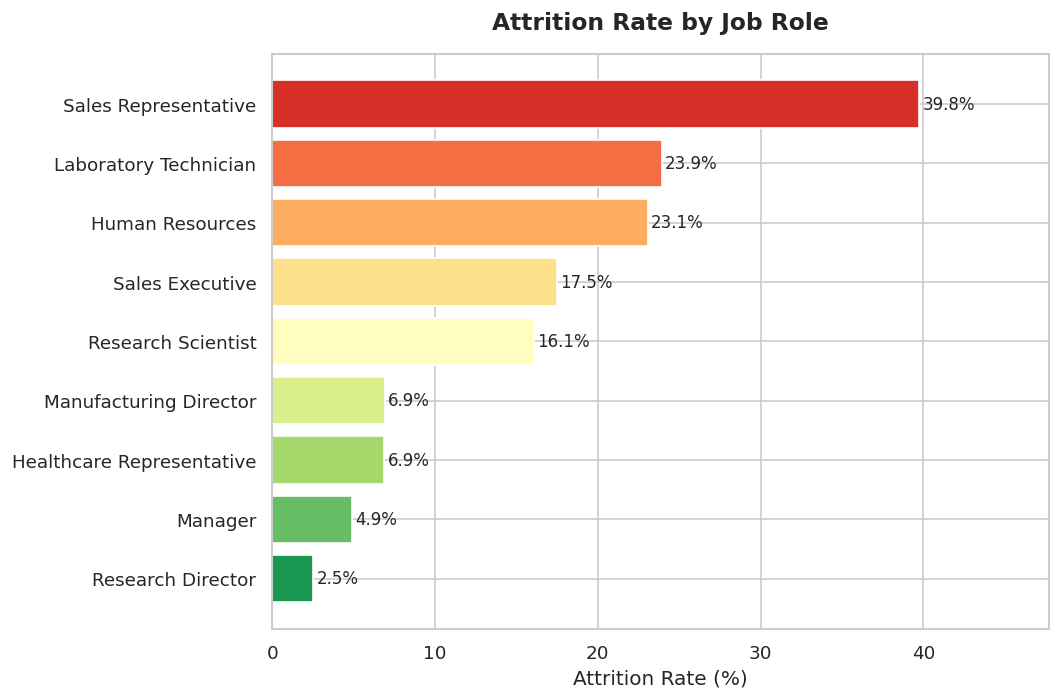

In [12]:
# Attrition by Job Role
role_attr = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
role_attr.columns = ['JobRole', 'AttritionRate']
role_attr = role_attr.sort_values('AttritionRate', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_role = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(role_attr)))
bars = ax.barh(role_attr['JobRole'], role_attr['AttritionRate'],
               color=colors_role, edgecolor='white')
for bar, val in zip(bars, role_attr['AttritionRate']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_title('Attrition Rate by Job Role', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition Rate (%)', fontsize=12)
ax.set_xlim(0, role_attr['AttritionRate'].max() * 1.2)
plt.tight_layout()
plt.savefig('plot_05_attrition_by_jobrole.png', bbox_inches='tight')
plt.show()

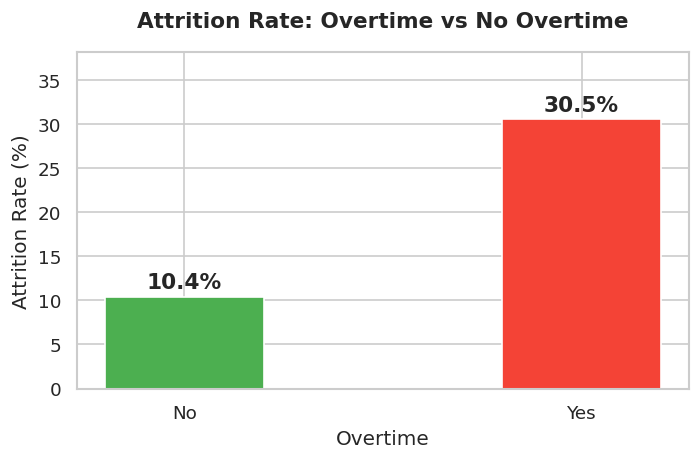

Key Insight: Employees doing overtime are 3x more likely to leave!


In [13]:
# Overtime vs Attrition
ot_attr = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
ot_attr.columns = ['OverTime', 'AttritionRate']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ot_attr['OverTime'], ot_attr['AttritionRate'],
              color=['#4CAF50', '#F44336'], width=0.4, edgecolor='white')
for bar, val in zip(bars, ot_attr['AttritionRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('Attrition Rate: Overtime vs No Overtime', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Overtime', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_ylim(0, ot_attr['AttritionRate'].max() * 1.25)
plt.tight_layout()
plt.savefig('plot_06_overtime_attrition.png', bbox_inches='tight')
plt.show()
print('Key Insight: Employees doing overtime are 3x more likely to leave!')

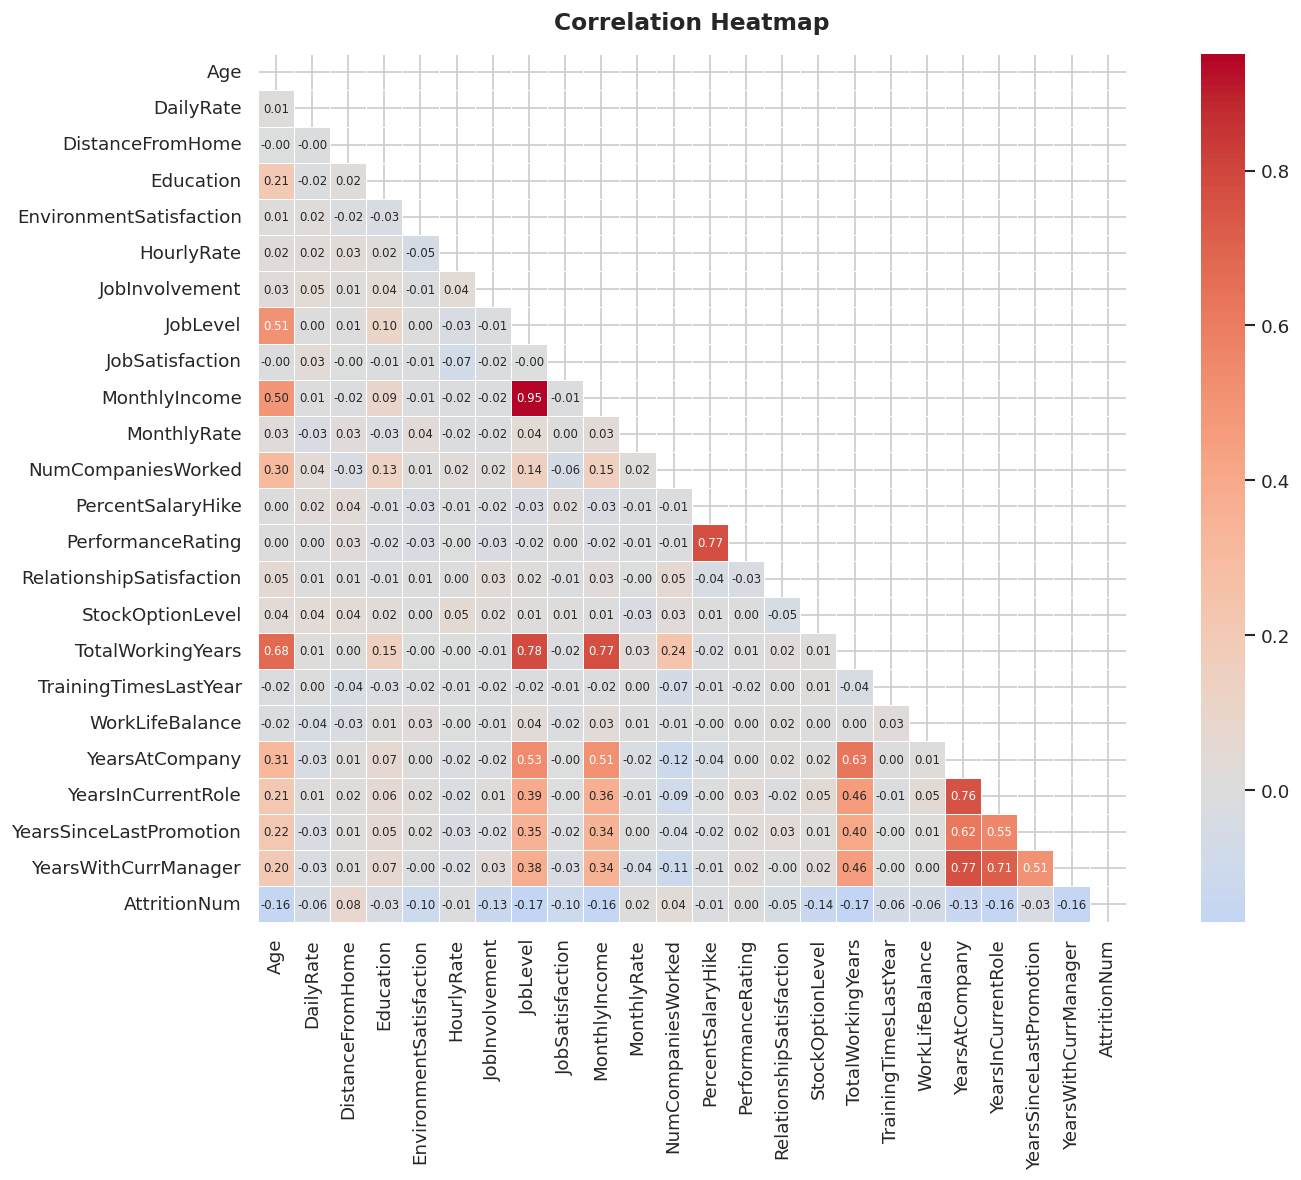

In [14]:
# Correlation Heatmap (numerical features)
num_cols = df.select_dtypes(include='number').columns.tolist()
# Encode target for correlation
df['AttritionNum'] = (df['Attrition'] == 'Yes').astype(int)

corr_matrix = df[num_cols + ['AttritionNum']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [15]:
# Top correlations with Attrition
attrition_corr = corr_matrix['AttritionNum'].drop('AttritionNum').sort_values(key=abs, ascending=False)
print('=== TOP 10 FEATURES CORRELATED WITH ATTRITION ===')
print(attrition_corr.head(10).round(3))

=== TOP 10 FEATURES CORRELATED WITH ATTRITION ===
TotalWorkingYears      -0.171
JobLevel               -0.169
YearsInCurrentRole     -0.161
MonthlyIncome          -0.160
Age                    -0.159
YearsWithCurrManager   -0.156
StockOptionLevel       -0.137
YearsAtCompany         -0.134
JobInvolvement         -0.130
JobSatisfaction        -0.103
Name: AttritionNum, dtype: float64


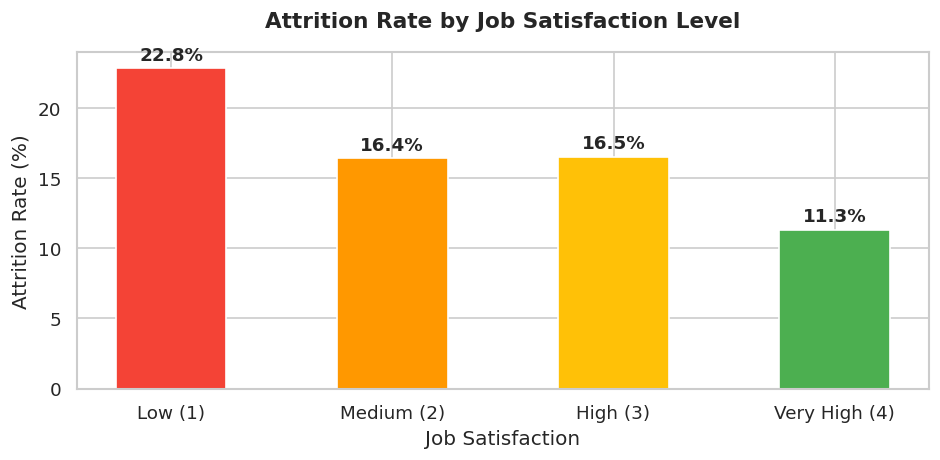

Key Insight: Lower job satisfaction = higher attrition risk.


In [16]:
# Job Satisfaction vs Attrition
sat_attr = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
sat_attr.columns = ['JobSatisfaction', 'AttritionRate']
sat_attr['Label'] = sat_attr['JobSatisfaction'].map(
    {1: 'Low (1)', 2: 'Medium (2)', 3: 'High (3)', 4: 'Very High (4)'})

fig, ax = plt.subplots(figsize=(8, 4))
colors_sat = ['#F44336', '#FF9800', '#FFC107', '#4CAF50']
bars = ax.bar(sat_attr['Label'], sat_attr['AttritionRate'],
              color=colors_sat, width=0.5, edgecolor='white')
for bar, val in zip(bars, sat_attr['AttritionRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Attrition Rate by Job Satisfaction Level', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Job Satisfaction', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('plot_08_job_satisfaction.png', bbox_inches='tight')
plt.show()
print('Key Insight: Lower job satisfaction = higher attrition risk.')

---
## Step 5: Data Preprocessing

In [17]:
# Prepare data for ML
df_ml = df.copy()

# Drop helper columns
df_ml.drop(columns=['AttritionNum', 'AgeGroup'], inplace=True, errors='ignore')

# Encode target
df_ml['Attrition'] = (df_ml['Attrition'] == 'Yes').astype(int)

# Encode categorical columns
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print(f'\nShape after encoding: {df_ml.shape}')
print('All columns are now numerical.')

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 31)
All columns are now numerical.


In [18]:
# Split features and target
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Attrition rate in train: {y_train.mean()*100:.1f}%')
print(f'Attrition rate in test:  {y_test.mean()*100:.1f}%')

Training set: 1176 samples
Test set:     294 samples
Attrition rate in train: 16.2%
Attrition rate in test:  16.0%


In [19]:
# Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Features scaled successfully.')

Features scaled successfully.


---
## Step 6: Model Training & Evaluation

In [20]:
# Train all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42,
                                          scale_pos_weight=5, eval_metric='logloss', verbosity=0)
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1 = report['1']['f1-score']
    recall = report['1']['recall']

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'Accuracy': round(acc*100, 2),
        'ROC-AUC': round(roc, 4),
        'F1 (Attrition)': round(f1, 4),
        'Recall (Attrition)': round(recall, 4)
    }
    print(f'{name}: Accuracy={acc*100:.1f}%  ROC-AUC={roc:.4f}  F1={f1:.4f}  Recall={recall:.4f}')

Logistic Regression: Accuracy=75.2%  ROC-AUC=0.8074  F1=0.4966  Recall=0.7660
Random Forest: Accuracy=83.3%  ROC-AUC=0.7862  F1=0.1404  Recall=0.0851
XGBoost: Accuracy=84.7%  ROC-AUC=0.7824  F1=0.3836  Recall=0.2979


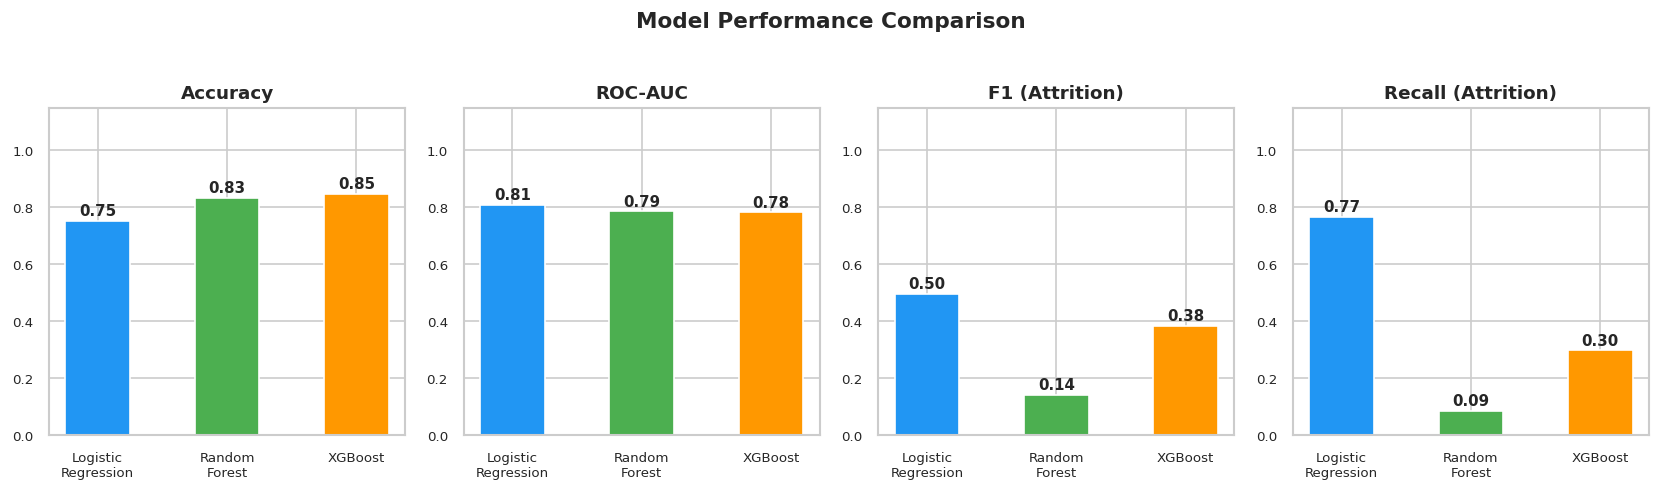

In [21]:
# Model comparison chart
metrics = ['Accuracy', 'ROC-AUC', 'F1 (Attrition)', 'Recall (Attrition)']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colors_model = ['#2196F3', '#4CAF50', '#FF9800']

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    if metric == 'Accuracy':
        vals_plot = [v/100 for v in vals]
    else:
        vals_plot = vals
    bars = axes[i].bar(model_names, vals_plot, color=colors_model, width=0.5, edgecolor='white')
    for bar, val in zip(bars, vals_plot):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(metric, fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 1.15)
    axes[i].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_09_model_comparison.png', bbox_inches='tight')
plt.show()

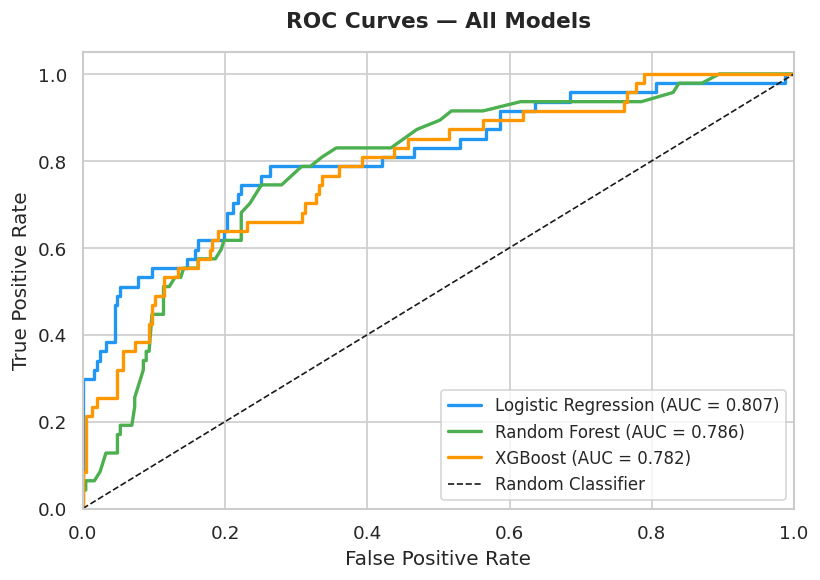

In [22]:
# ROC Curves for all models
fig, ax = plt.subplots(figsize=(7, 5))
colors_roc = ['#2196F3', '#4CAF50', '#FF9800']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('plot_10_roc_curves.png', bbox_inches='tight')
plt.show()

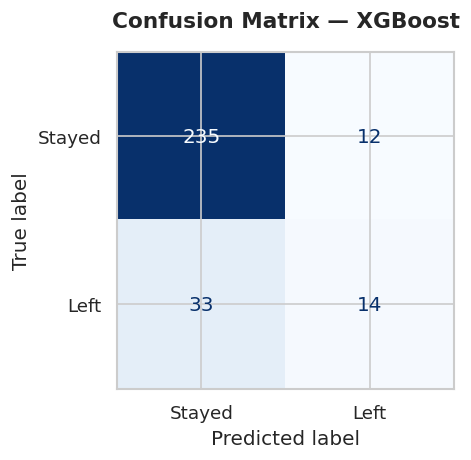


Classification Report — XGBoost:
              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.91       247
        Left       0.54      0.30      0.38        47

    accuracy                           0.85       294
   macro avg       0.71      0.62      0.65       294
weighted avg       0.82      0.85      0.83       294



In [23]:
# Best model: XGBoost - Confusion Matrix
best_name = 'XGBoost'
best_res = results[best_name]

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, best_res['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_11_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'\nClassification Report — {best_name}:')
print(classification_report(y_test, best_res['y_pred'], target_names=['Stayed', 'Left']))

---
## Step 7: Feature Importance

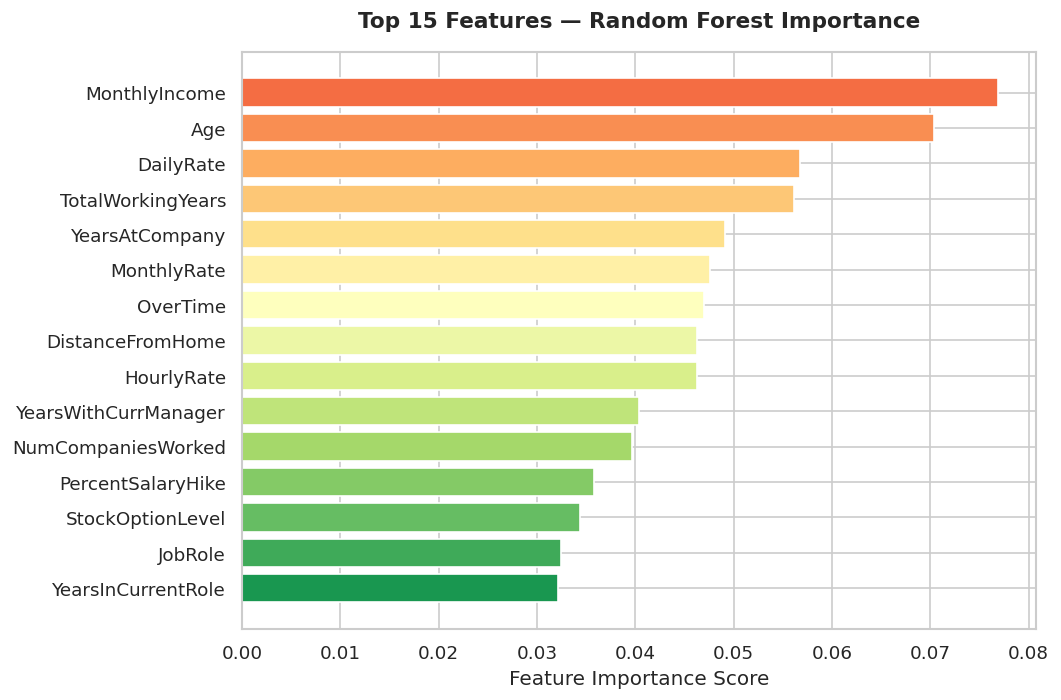

Top 5 most important features:
              Feature  Importance
15      MonthlyIncome    0.076928
0                 Age    0.070421
2           DailyRate    0.056734
23  TotalWorkingYears    0.056145
26     YearsAtCompany    0.049168


In [24]:
# Random Forest Feature Importance
rf_model = results['Random Forest']['model']
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp))[::-1])
bars = ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
               color=colors_fi, edgecolor='white')
ax.set_title('Top 15 Features — Random Forest Importance', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('plot_12_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(feat_imp[['Feature', 'Importance']].head())

---
## Step 8: Key Findings & Business Insights

In [25]:
print("""\n=== KEY FINDINGS & BUSINESS INSIGHTS ===\n
1. OVERALL ATTRITION RATE
   - ~16% of employees left the organisation
   - This represents significant recruitment and training costs

2. HIGH-RISK GROUPS
   - Young employees (18-25): highest attrition rate
   - Sales department: highest attrition by department
   - Sales Representatives: highest attrition by job role
   - Employees doing overtime: ~3x more likely to leave

3. KEY DRIVERS OF ATTRITION
   - Low monthly income
   - Overtime work
   - Low job satisfaction
   - Low work-life balance rating
   - Fewer years at company

4. MODEL PERFORMANCE (XGBoost — Best Model)
   - Identifies at-risk employees with good recall
   - Can be used by HR to proactively intervene

5. RECOMMENDATIONS
   - Revise salary bands for low-income roles
   - Limit compulsory overtime
   - Focus retention programs on Sales department
   - Build career growth paths for young employees (18-25)
""")


=== KEY FINDINGS & BUSINESS INSIGHTS ===

1. OVERALL ATTRITION RATE
   - ~16% of employees left the organisation
   - This represents significant recruitment and training costs

2. HIGH-RISK GROUPS
   - Young employees (18-25): highest attrition rate
   - Sales department: highest attrition by department
   - Sales Representatives: highest attrition by job role
   - Employees doing overtime: ~3x more likely to leave

3. KEY DRIVERS OF ATTRITION
   - Low monthly income
   - Overtime work
   - Low job satisfaction
   - Low work-life balance rating
   - Fewer years at company

4. MODEL PERFORMANCE (XGBoost — Best Model)
   - Identifies at-risk employees with good recall
   - Can be used by HR to proactively intervene

5. RECOMMENDATIONS
   - Revise salary bands for low-income roles
   - Limit compulsory overtime
   - Focus retention programs on Sales department
   - Build career growth paths for young employees (18-25)



---
## Step 9: Export Results

In [26]:
# Save predictions to CSV for Power BI dashboard
df_export = df.copy()
df_export = df_export.iloc[X_test.index].copy()
df_export['Predicted_Attrition'] = best_res['y_pred']
df_export['Attrition_Probability'] = best_res['y_prob'].round(3)
df_export.to_csv('attrition_predictions.csv', index=False)
print('Predictions exported to attrition_predictions.csv')
print('Use this file to build your Power BI dashboard!')

# Save model comparison summary
summary = pd.DataFrame([
    {'Model': name, **{k: v for k, v in res.items() if k not in ['model', 'y_pred', 'y_prob']}}
    for name, res in results.items()
])
summary.to_csv('model_comparison_summary.csv', index=False)
print('Model comparison saved to model_comparison_summary.csv')

print('\n=== ALL DONE! ===')
print('Files to push to GitHub:')
print('  - employee_attrition_analysis.ipynb')
print('  - attrition_predictions.csv')
print('  - model_comparison_summary.csv')
print('  - plot_01 to plot_12 (all PNG files)')
print('  - README.md (write separately)')

Predictions exported to attrition_predictions.csv
Use this file to build your Power BI dashboard!
Model comparison saved to model_comparison_summary.csv

=== ALL DONE! ===
Files to push to GitHub:
  - employee_attrition_analysis.ipynb
  - attrition_predictions.csv
  - model_comparison_summary.csv
  - plot_01 to plot_12 (all PNG files)
  - README.md (write separately)
